BMI 500: Scanpy PBMC profiling (partial homework report)

Evidence and method

All measurements come from successful OddJobs Slurm jobs 1289747, 1289760, and 1289774. No synthetic timing data are included. Each run requested one CPU, 16 GiB memory, and two hours. /usr/bin/time -v wrapped Python inside srun. SectionTimer used time.time() at all 16 starter section boundaries. Only the final rank_genes_groups call was instrumented with cProfile.

Scanpy 1.10.2 and Python 3.12.13 were used. requirements-oddjobs.txt and per-run environment.txt record installed versions. AnnData 0.10.8, Zarr 2.18.7, and setuptools 80.9.0 resolved observed import failures. Scanpy read caching was disabled; each run used a separate NUMBA_CACHE_DIR. OS filesystem caches and all library caches were not controlled.

Observed process measurements

pbmc3k-1289747: 2700 input cells, 2700 analyzed cells, 4 clusters; wall 40.81 s, user CPU 31.81 s, system CPU 5.84 s, CPU utilization 92%, peak RSS 910040 KiB (888.7 MiB). Host: bignode2.priv.bmi.emory.edu.

pbmc6k-1289760: 5419 input cells, 5418 analyzed cells, 7 clusters; wall 44.79 s, user CPU 41.36 s, system CPU 1.56 s, CPU utilization 95%, peak RSS 986612 KiB (963.5 MiB). Host: bignode7.priv.bmi.emory.edu.

pbmc10k-1289774: 11769 input cells, 11537 analyzed cells, 16 clusters; wall 87.52 s, user CPU 80.86 s, system CPU 5.82 s, CPU utilization 99%, peak RSS 1937848 KiB (1892.4 MiB). Host: bignode2.priv.bmi.emory.edu.

Bottlenecks and interpretation

Settings is the largest measured 3K section (15.05 s); UMAP is the largest 6K section (15.90 s); neighbors is the largest 10K section (33.04 s). The settings section includes print_header and figure setup; it was not profiled internally, so its specific cause cannot be established. Among biological analysis steps, UMAP dominates 3K and 6K. The 10K rank_genes_groups step takes 14.24 s and UMAP takes 14.37 s.

UMAP is faster at 10K than at 6K, while neighbors jumps from 4.57 to 33.04 s. These observations do not establish a smooth scaling law. Possible contributors include algorithm paths, JIT compilation, data structure, node performance and contention; these were not isolated.

pbmc3k cProfile: pandas algorithms.rank self time is 1.381 s, 73.6% of total profiled self time. This supports ranking as a major cost within the Wilcoxon marker-gene calculation.

pbmc6k cProfile: pandas algorithms.rank self time is 2.507 s, 71.2% of total profiled self time. This supports ranking as a major cost within the Wilcoxon marker-gene calculation.

pbmc10k cProfile: pandas algorithms.rank self time is 8.304 s, 58.4% of total profiled self time. This supports ranking as a major cost within the Wilcoxon marker-gene calculation.

The pipeline selects 2000 variable genes for dimensionality reduction, but adata.raw is captured before this selection and rank_genes_groups uses use_raw=True. Marker testing therefore includes the retained genes in raw, not only the 2000 selected genes. Group count also changes from 4 to 7 to 16, so cell count alone cannot explain marker-test scaling.

20K estimate: scenario, not a measured result

Define 20K as 20000 input cells. Use the actual 10K input size of 11769 cells, giving a scale factor of 1.6994. Hold imports, settings, argument handling and empty placeholders constant. Multiply all other 10K section times by this factor. This assumes similar filtering fraction, gene count, sparsity, cluster structure, hardware and algorithm behavior.

The section-sum estimate is 135.52 s. It excludes recorder and process overhead and is not a prediction of exact /usr/bin/time wall time. As an alternative assumption, quadratic scaling of data-dependent sections gives 219.13 s. These are two sensitivity scenarios, not confidence bounds. estimate_20k.csv lists every section.

20K per-section linear scenario (seconds)

imports: 2.640432 (constant).

settings: 13.343091 (constant).

arguments: 0.001597 (constant).

read_data: 6.182641 (linear in input cells).

filter: 0.712608 (linear in input cells).

normalize_log: 0.770920 (linear in input cells).

highly_variable_genes: 2.359457 (linear in input cells).

scale: 0.317721 (linear in input cells).

report_placeholder: 0.000004 (constant).

pca: 1.856612 (linear in input cells).

neighbors: 56.139685 (linear in input cells).

paga_placeholder: 0.000004 (constant).

louvain: 1.350279 (linear in input cells).

umap: 24.422353 (linear in input cells).

write_h5ad: 1.232754 (linear in input cells).

rank_genes_groups: 24.192790 (linear in input cells).

Limits and submission status

There is only one successful run per dataset, on two nodes. The 3K script used default CPU binding; 6K and 10K explicitly used --cpu-bind=cores after two failed launches. Thus this is an exploratory comparison, not a controlled benchmark. Repeats with matching node type and binding would be needed to quantify variability. Failed jobs 1289755 and 1289757 are excluded from all measurements.

The total process time includes imports, profiling and output overhead. Section times omit timer printing and CSV writes. The final section includes cProfile setup and profile dumping. Cumulative cProfile times overlap across callers and callees and must not be summed. Self time excludes called functions. The profiler introduces overhead.

The h5ad write stays in the starter location before marker testing, so that file does not contain the subsequent marker results. Peak RSS is process-wide; there are no per-section memory measurements. The sparse matrix is densified during scale, as noted in the console warnings.

This report and notebook cover profiling only. They are not the final complete homework submission. The Python Quiz remains entirely the student's work. Class-partner manual review and a different assistant's AI review remain outstanding. No such reviews are generated here.

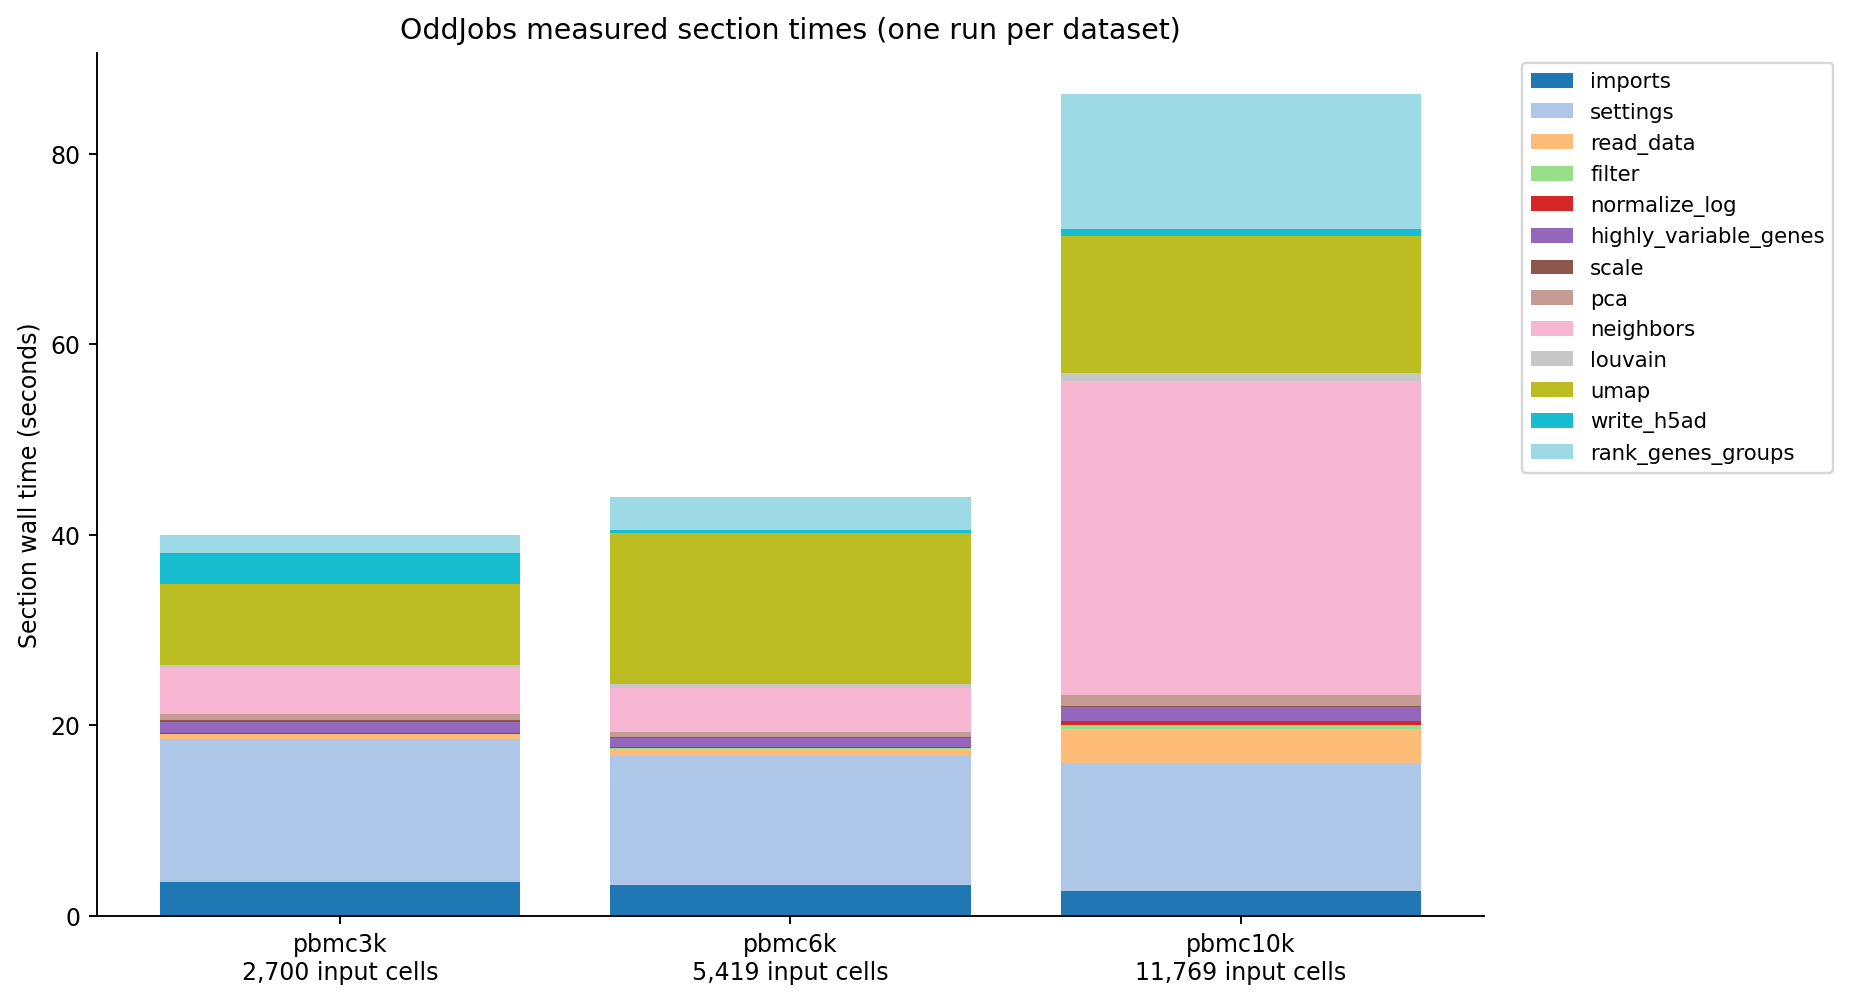

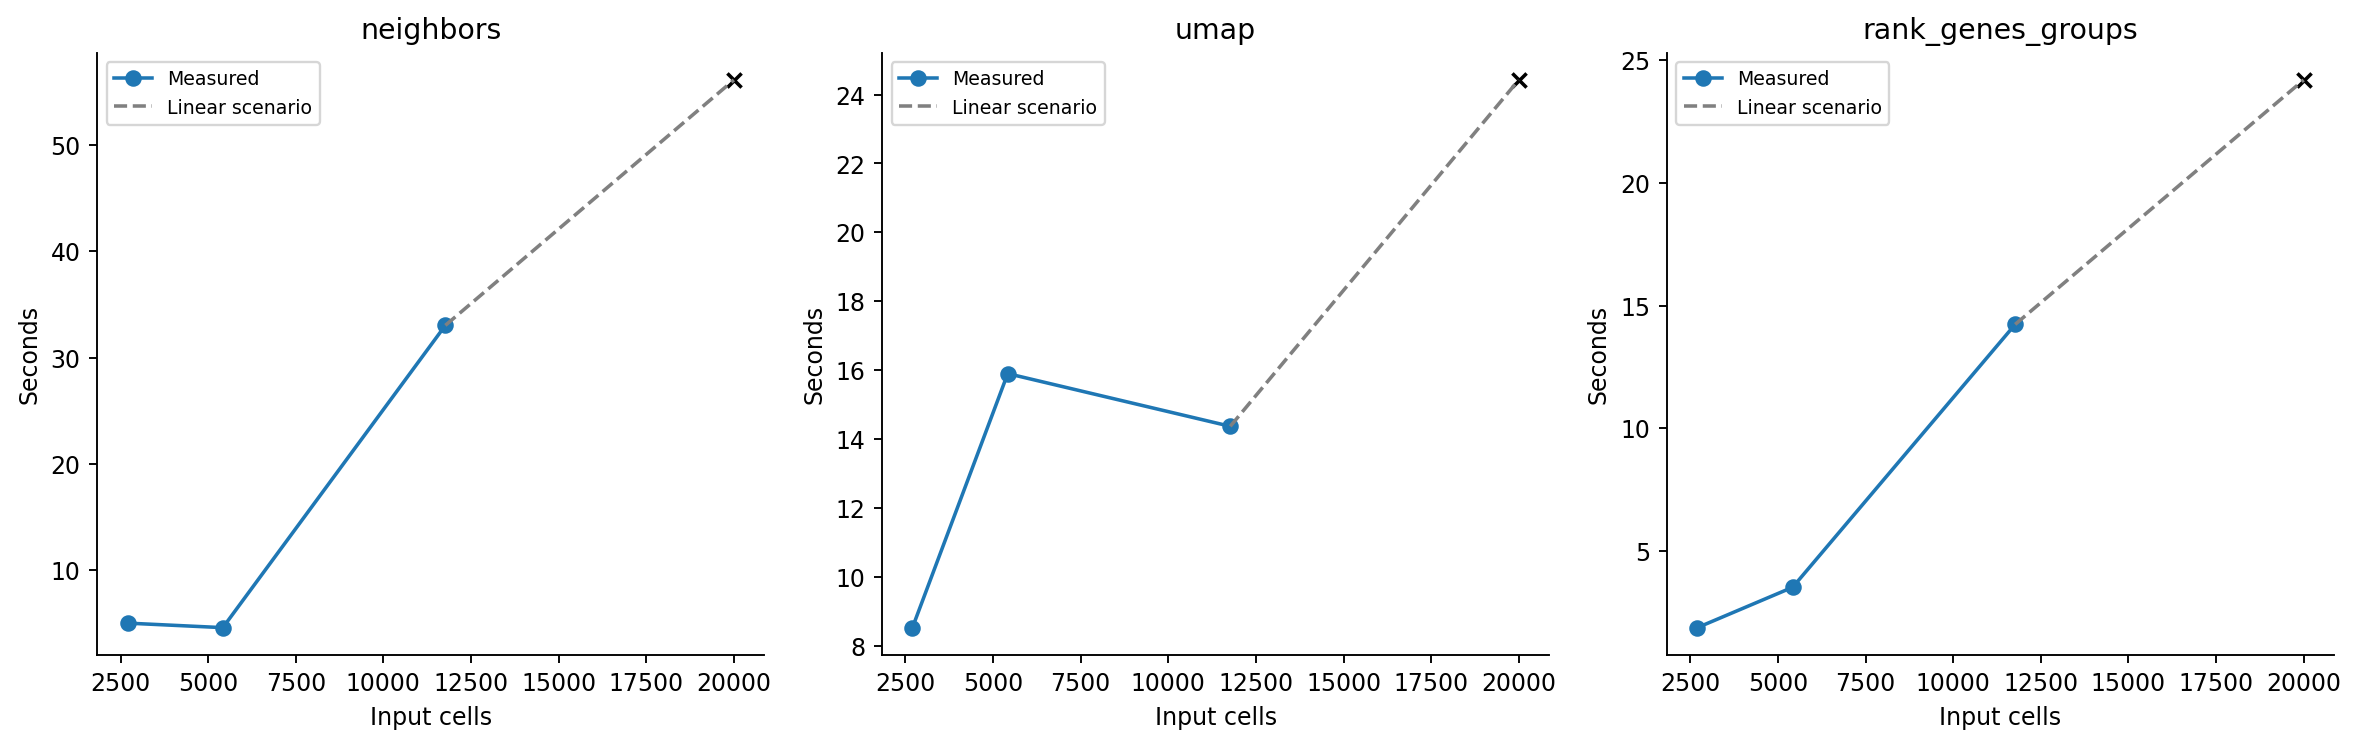

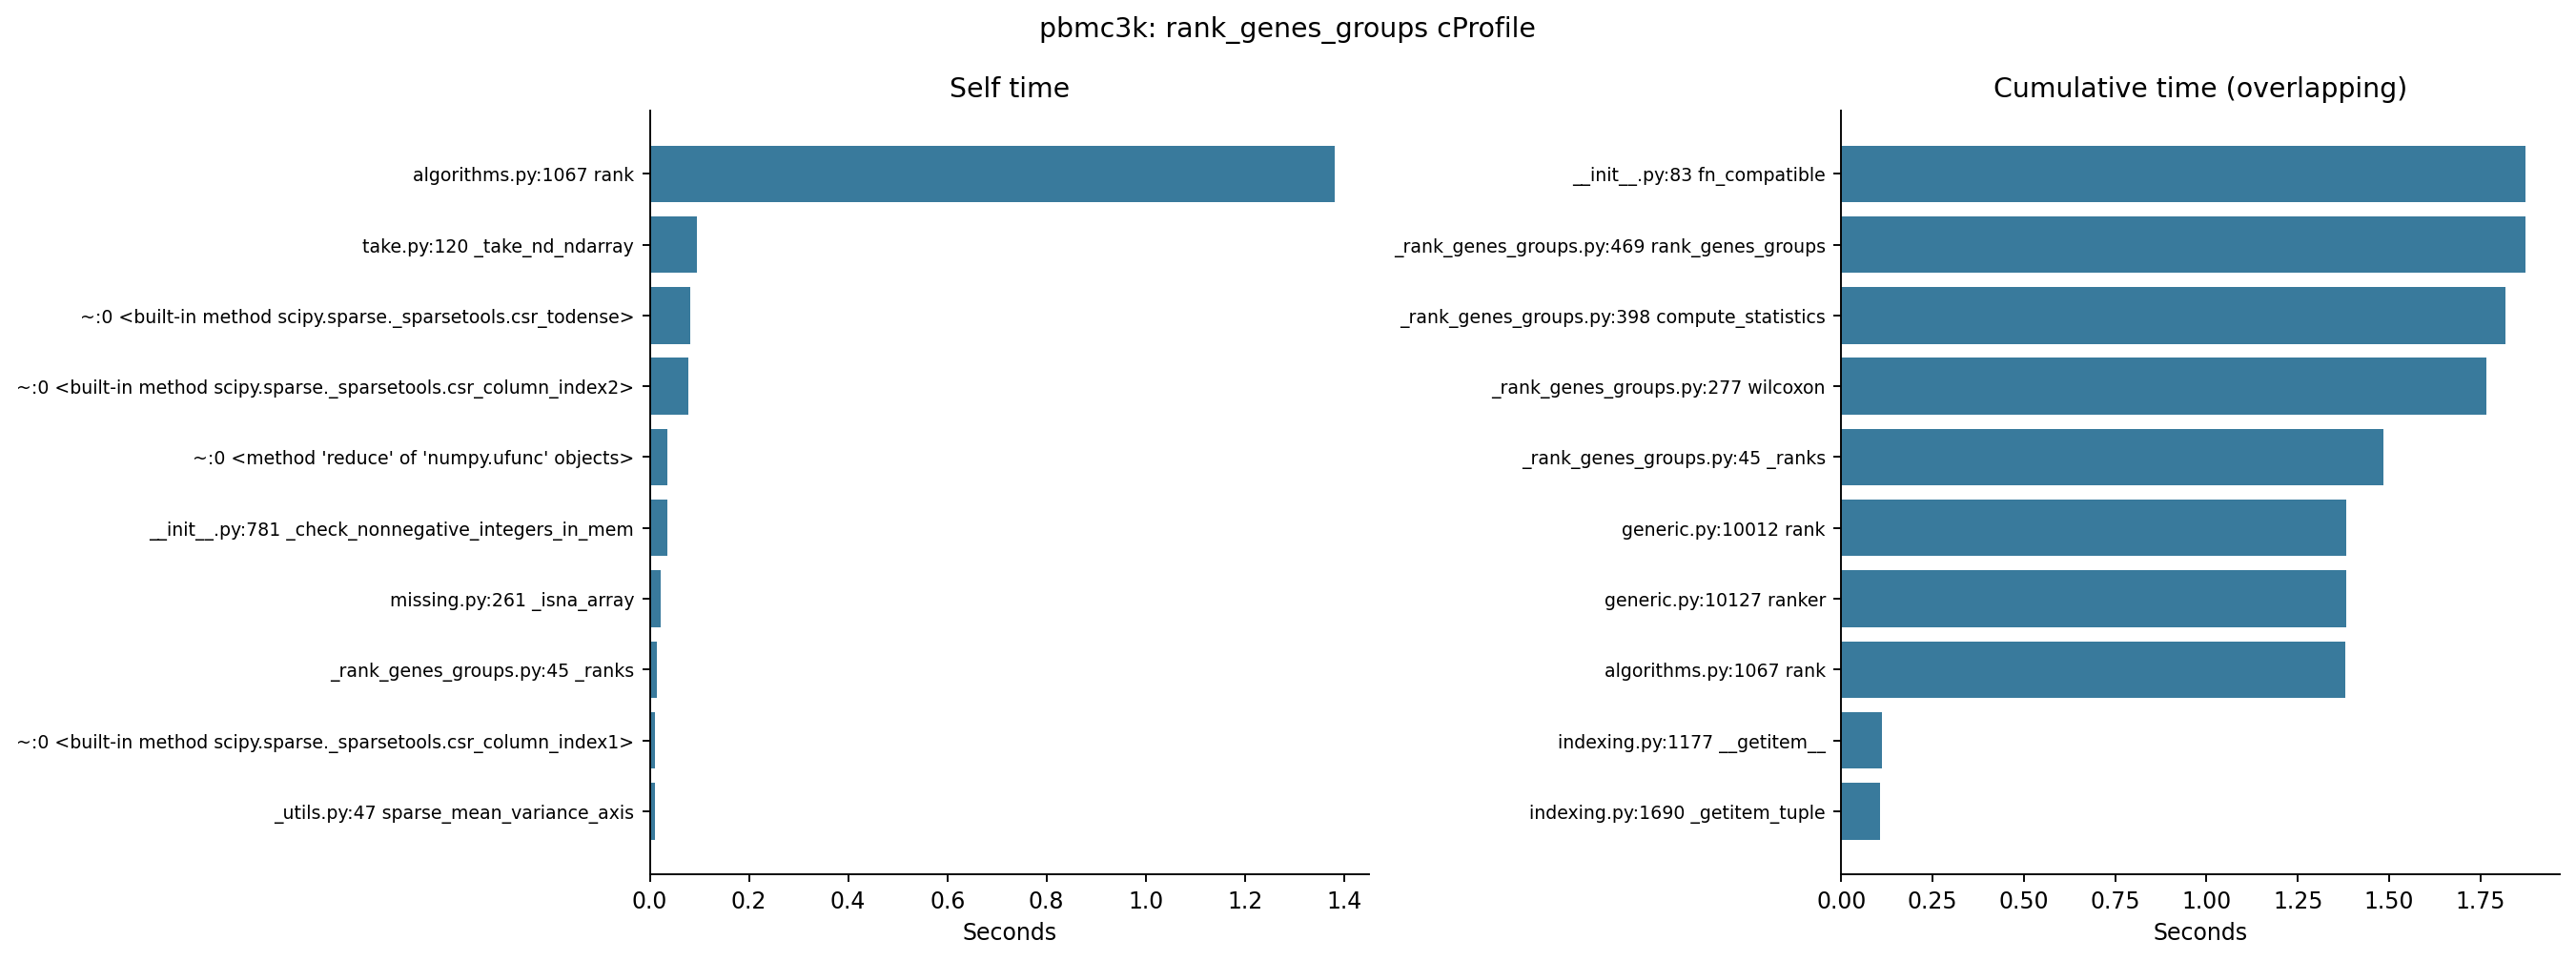

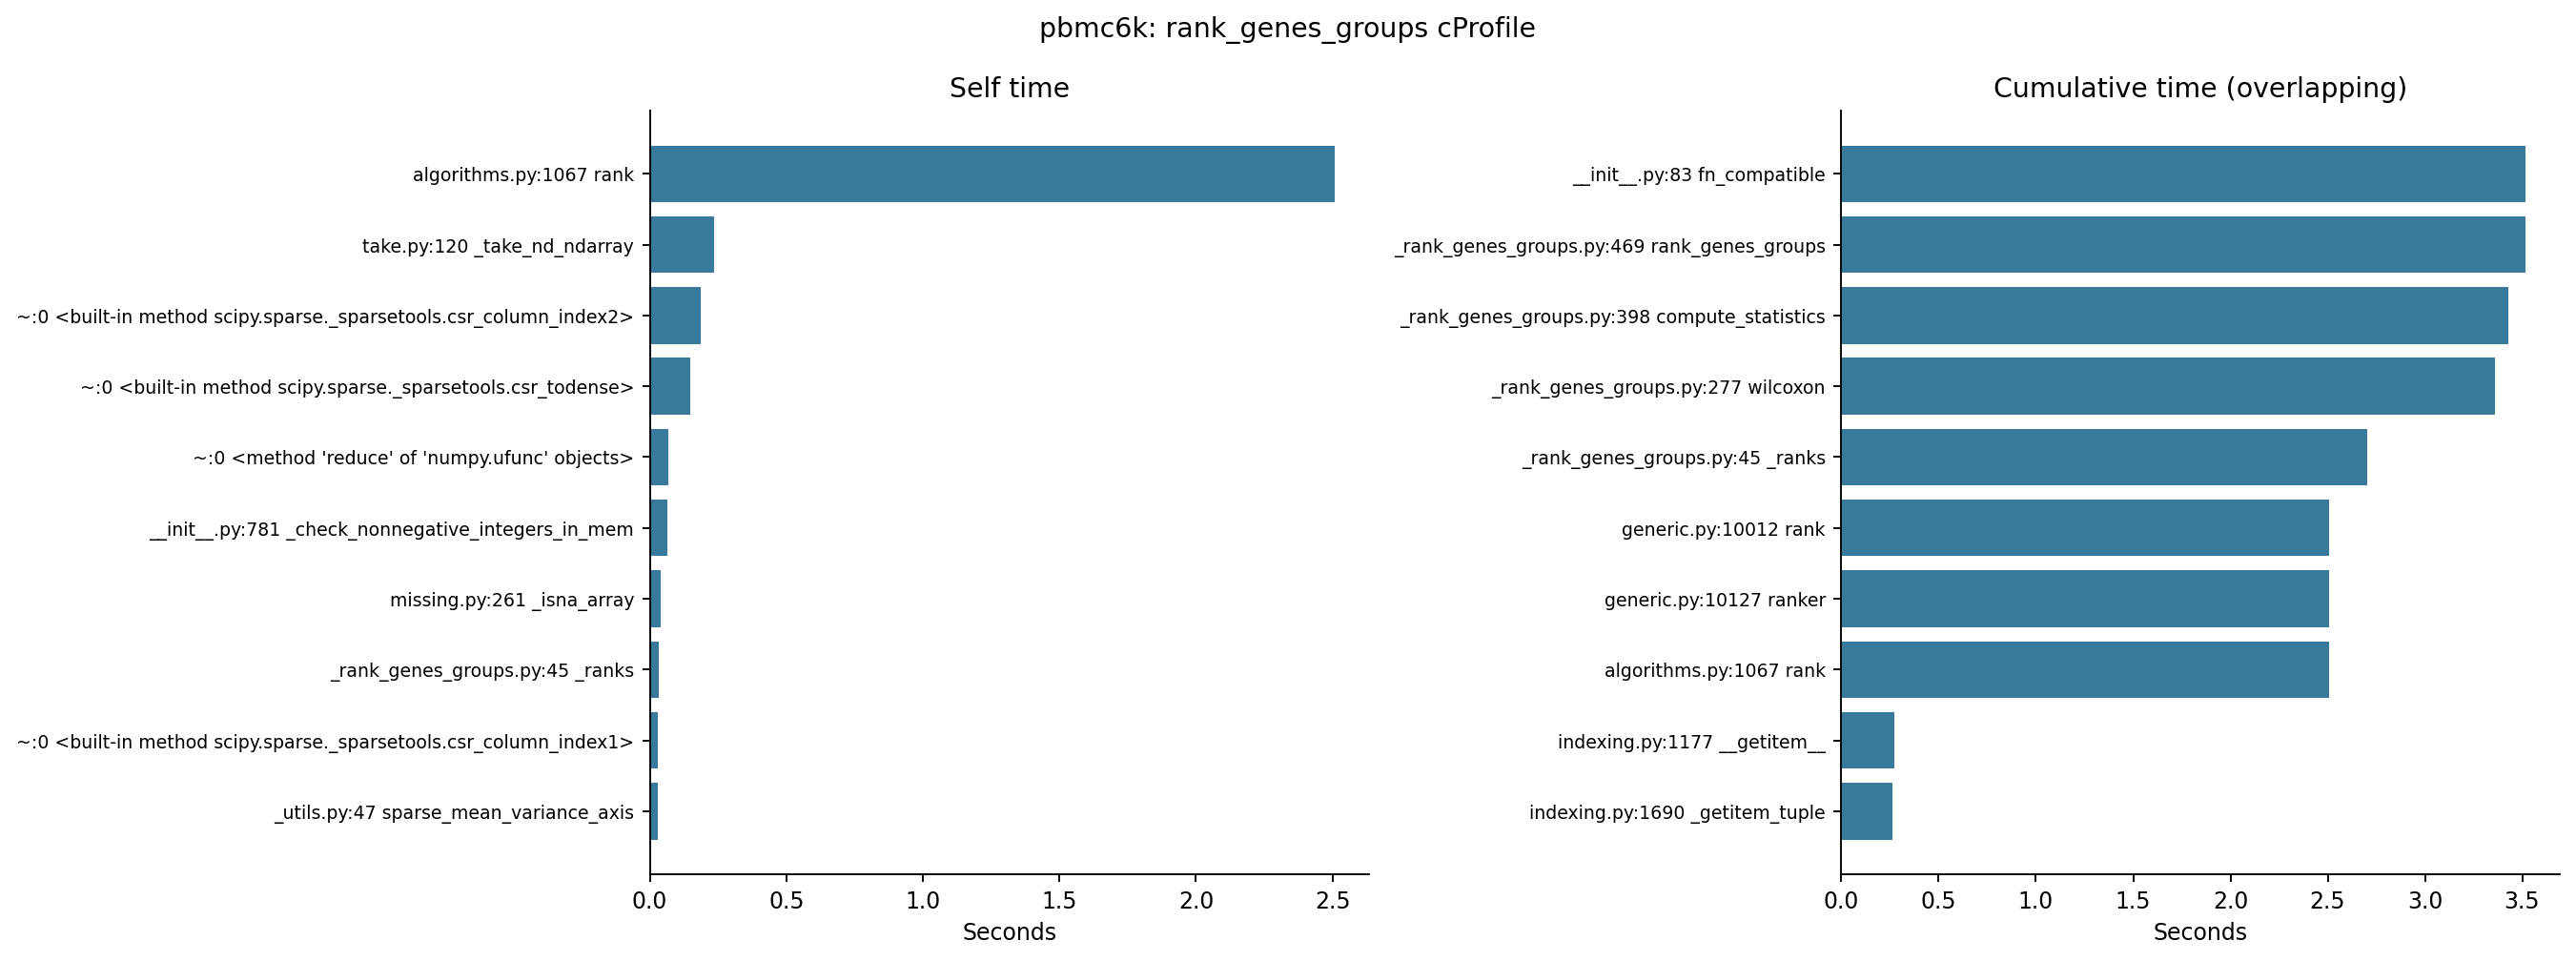

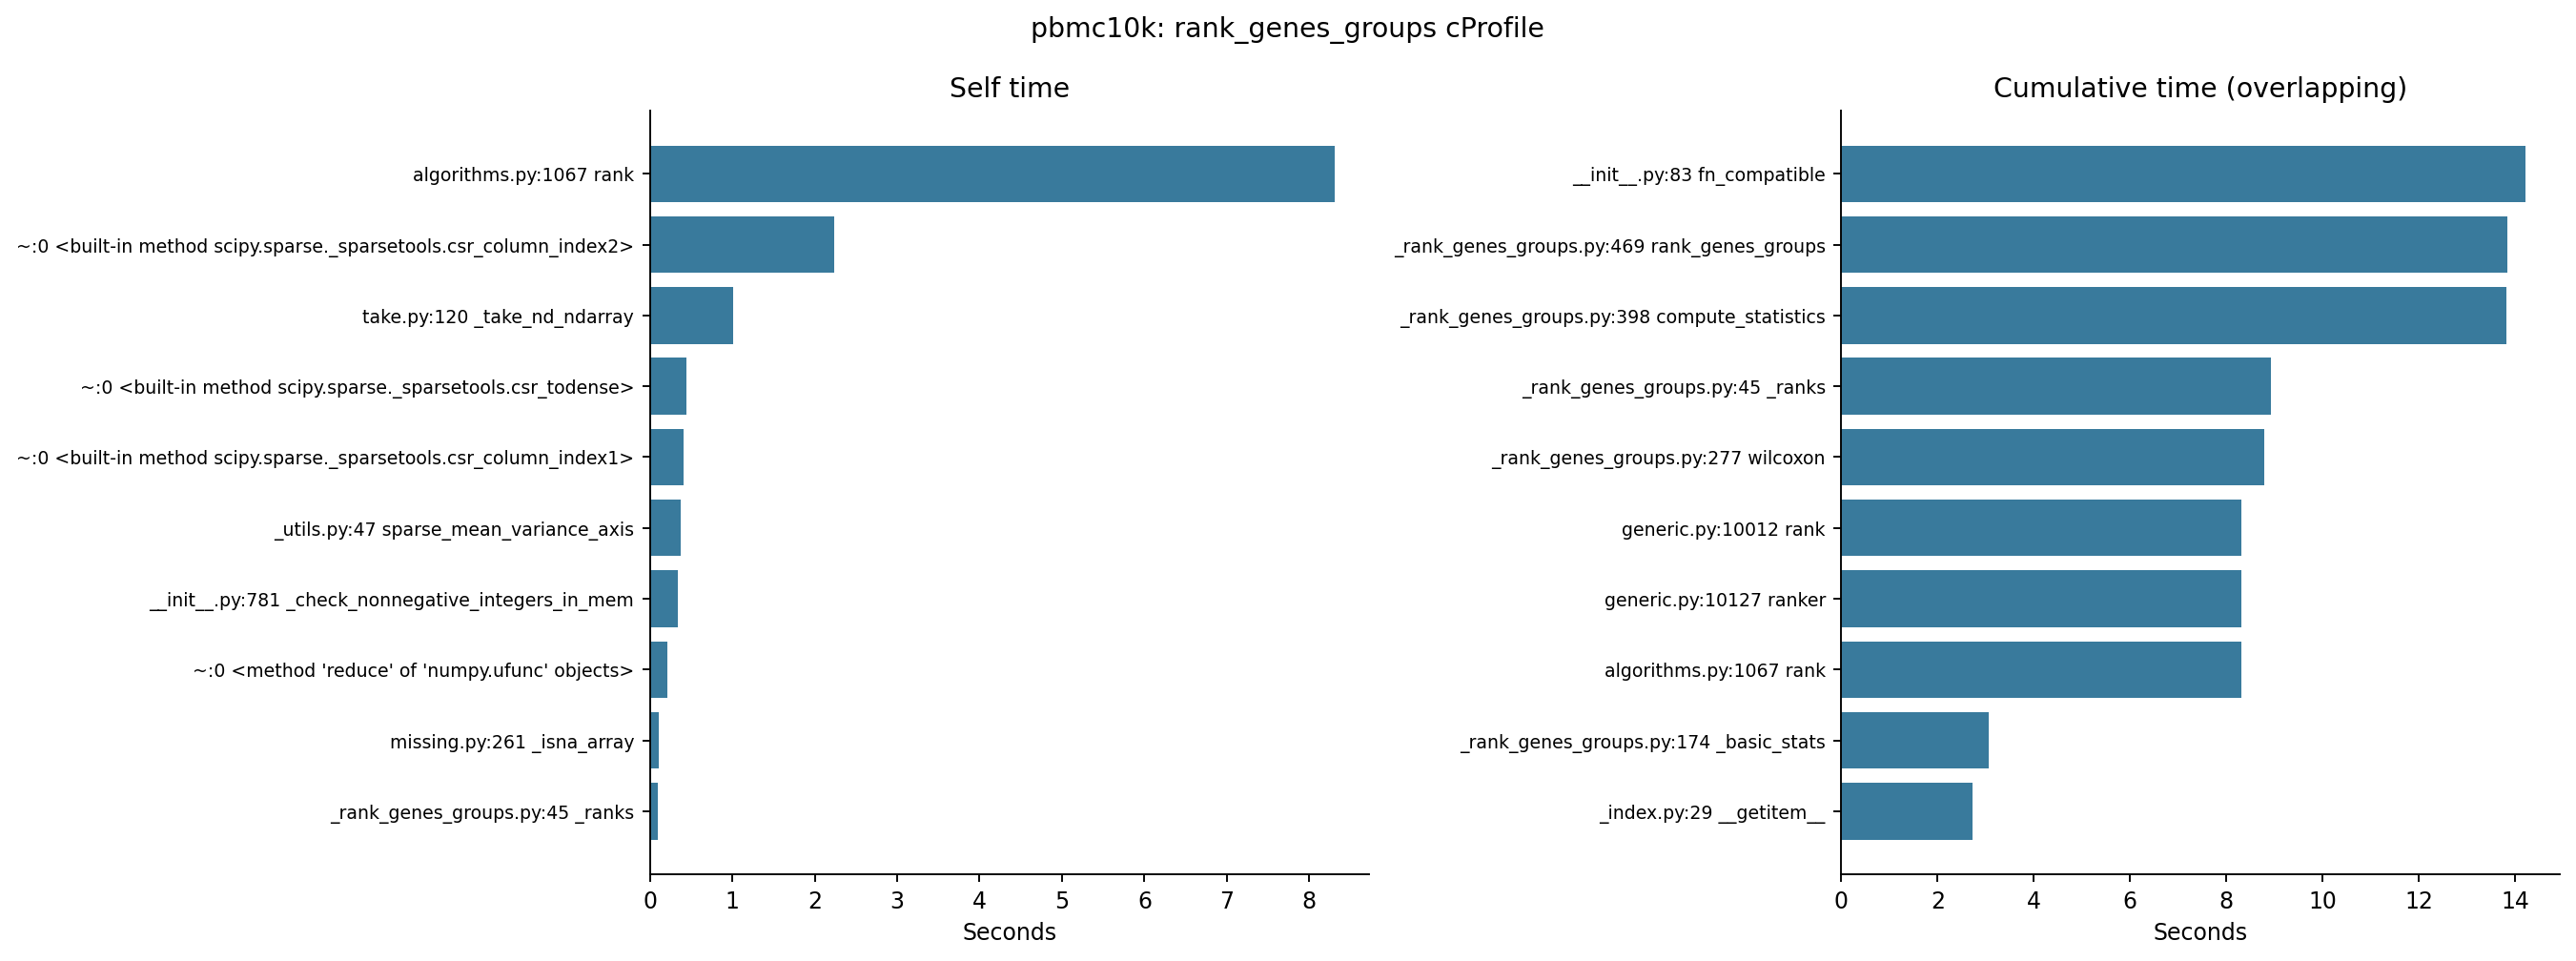

In [ ]:
# Optional local regeneration from the repository root:
import subprocess, sys
subprocess.run([sys.executable, "analyze_profiles.py"], check=True)
